# Material-Specific Workflows: MoS₂ and Graphene

This notebook demonstrates complete workflows for simulating quantum CTEM of specific materials using QuScope.

## Materials Covered

1. **MoS₂ (Molybdenum Disulfide)** - Transition metal dichalcogenide
2. **Graphene** - 2D carbon allotrope

Each workflow includes:
- Material structure and properties
- Quantum circuit construction
- CTEM simulation
- Analysis and visualization

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Circle

# QuScope imports
import quscope
from quscope.quantum_ctem.backends import get_backend
from quscope.quantum_ctem.materials import get_material
from quscope.quantum_ctem.workflows import MoS2Workflow, GrapheneWorkflow

print(f"QuScope v{quscope.__version__}")

# Initialize backend
backend = get_backend('simulator')
print(f"Backend: {backend.name}")

QuScope v0.1.2
Backend: simulator_statevector


## Part 1: MoS₂ (Molybdenum Disulfide)

MoS₂ is a layered material with a hexagonal structure. Each layer consists of Mo atoms sandwiched between two S layers.

### 1.1 Material Properties

In [2]:
# Load MoS2 material
mos2 = get_material('mos2')

print(f"Material: {mos2.name}")
print(f"Chemical formula: {mos2.formula}")
print(f"\nLattice Parameters:")
print(f"  a = {mos2.parameters.a:.4f} Å")
print(f"  c = {mos2.parameters.c:.4f} Å")
print(f"\nElements: {mos2.parameters.elements}")

# Build atomic structure (returns a real ASE Atoms object)
structure = mos2.build_structure(nx=2, ny=2)
print(f"\nSupercell (2×2×1):")
print(f"  Total atoms: {len(structure)}")


Material: Molybdenum Disulfide
Chemical formula: MoS₂

Lattice Parameters:
  a = 3.1600 Å
  c = 12.2900 Å

Elements: ['Mo', 'S']



Supercell (2×2×1):
  Total atoms: 12


### 1.2 Visualize MoS₂ Structure

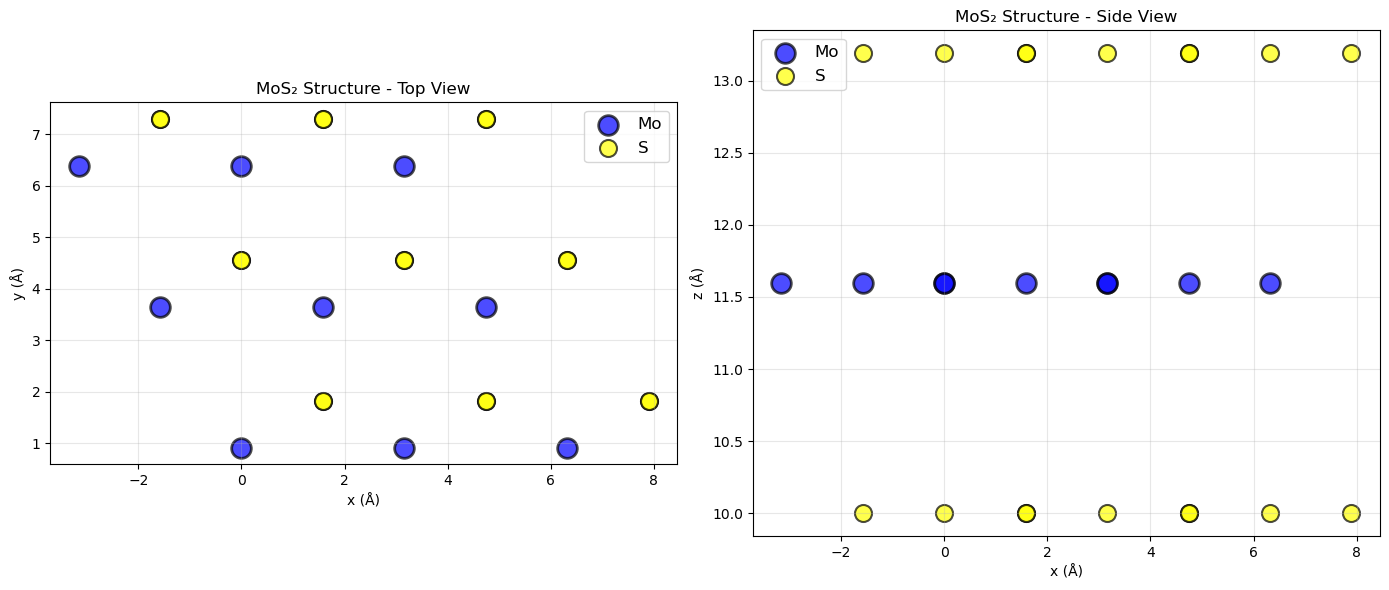

Number of Mo atoms: 9
Number of S atoms: 18
S/Mo ratio: 2.0


In [3]:
# Visualize atomic positions
structure = mos2.build_structure(nx=3, ny=3)
positions = structure.get_positions()
atomic_numbers = structure.get_atomic_numbers()

# Separate Mo and S atoms
mo_pos = positions[atomic_numbers == 42]  # Mo: Z=42
s_pos = positions[atomic_numbers == 16]   # S: Z=16

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Top view
axes[0].scatter(mo_pos[:, 0], mo_pos[:, 1], s=200, c='blue', 
                label='Mo', alpha=0.7, edgecolors='black', linewidths=2)
axes[0].scatter(s_pos[:, 0], s_pos[:, 1], s=150, c='yellow', 
                label='S', alpha=0.7, edgecolors='black', linewidths=1.5)
axes[0].set_xlabel('x (Å)')
axes[0].set_ylabel('y (Å)')
axes[0].set_title('MoS₂ Structure - Top View')
axes[0].legend(fontsize=12)
axes[0].set_aspect('equal')
axes[0].grid(True, alpha=0.3)

# Side view (looking along y-axis)
axes[1].scatter(mo_pos[:, 0], mo_pos[:, 2], s=200, c='blue', 
                label='Mo', alpha=0.7, edgecolors='black', linewidths=2)
axes[1].scatter(s_pos[:, 0], s_pos[:, 2], s=150, c='yellow', 
                label='S', alpha=0.7, edgecolors='black', linewidths=1.5)
axes[1].set_xlabel('x (Å)')
axes[1].set_ylabel('z (Å)')
axes[1].set_title('MoS₂ Structure - Side View')
axes[1].legend(fontsize=12)
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f"Number of Mo atoms: {len(mo_pos)}")
print(f"Number of S atoms: {len(s_pos)}")
print(f"S/Mo ratio: {len(s_pos)/len(mo_pos):.1f}")


### 1.3 MoS₂ Quantum CTEM Workflow

In [4]:
# Initialize MoS2 workflow. Voltage/defocus/Cs are configured at construction
# time (defocus defaults to the Scherzer value for the given Cs/voltage);
# grid_size/pixel_size/apply_ctf/compare_classical are passed to run().
mos2_workflow = MoS2Workflow(backend=backend, voltage=200e3, cs=1.3)
print(f"Scherzer defocus: {mos2_workflow.microscope.defocus:.1f} Å")

# grid_size x pixel_size sets the field of view (9.6x9.6 A here), matched to
# the 3x3 MoS2 supercell (9.48x8.21 A) built below.
print("\nRunning quantum CTEM simulation...")
result = mos2_workflow.run(
    nx=3, ny=3, grid_size=64, pixel_size=0.15,
    apply_ctf=True, compare_classical=True,
)

print("\nSimulation complete!")
print(result.summary())


Scherzer defocus: -685.2 Å

Running quantum CTEM simulation...



Simulation complete!
=== Quantum CTEM Simulation Result ===
Material: Molybdenum Disulfide
Supercell: 3×3 (27 atoms)
Grid: 64×64 px (0.150 Å/px)
Field of view: 9.5×8.2 Å

Quantum Circuit:
  Qubits: 12
  Depth: 5
  Execution time: 1.853 s

Microscope:
  Voltage: 200 kV
  Defocus: -685.2 Å
  Cs: 1.3 mm

Validation:
  Correlation with classical: 1.0000


### 1.4 Analyze MoS₂ Results

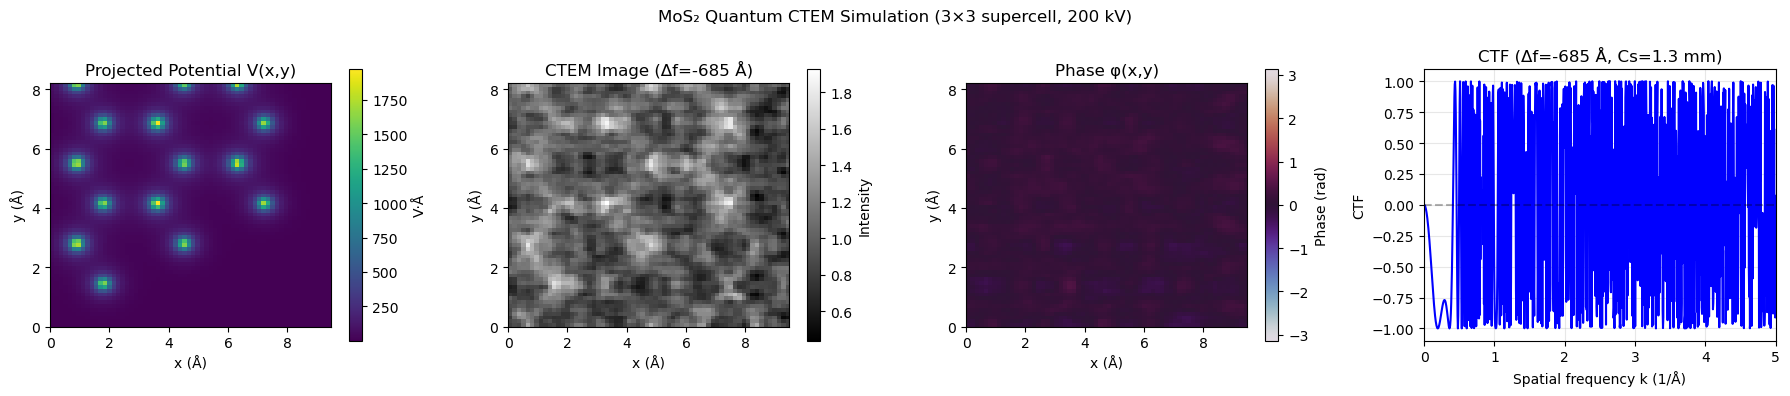

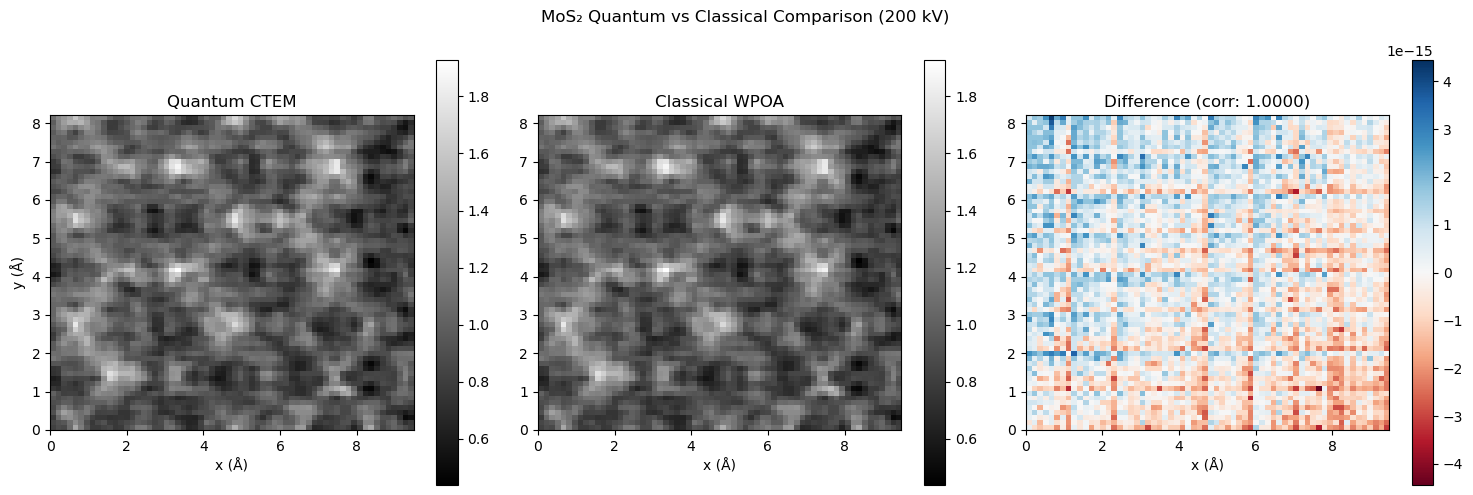

Potential range: [0.00, 1975.90] V·Å
Circuit: 12 qubits, depth 5
Quantum-classical correlation: 1.000000


In [5]:
# Visualize results with the workflow's built-in plotting (uses
# result.projected_potential / .intensity / .phase under the hood, all in
# real V·Å / intensity / rad units)
fig = mos2_workflow.visualize(
    result, show_potential=True, show_intensity=True, show_phase=True,
    show_ctf=True, figsize=(18, 4),
)
plt.show()

# Quantum vs classical comparison (the classical twin uses the SAME
# QuantumClassicalValidator physics as the paper and the rest of the package)
fig2 = mos2_workflow.compare_with_classical(result)
plt.show()

print(f"Potential range: [{result.projected_potential.min():.2f}, "
      f"{result.projected_potential.max():.2f}] V·Å")
print(f"Circuit: {result.n_qubits} qubits, depth {result.circuit_depth}")
print(f"Quantum-classical correlation: {result.correlation_coefficient:.6f}")


**A note on image appearance:** the CTEM images above can look grainy/speckled
rather than showing crisp atomic contrast. This is a genuine, validated numerical
effect, not a bug: at Scherzer defocus the lens aberration function chi(k) oscillates
extremely rapidly in k, and this notebook uses a deliberately small field of view
(≈10 Å) for fast execution, so the k-space grid spacing is far coarser than chi(k)'s
own oscillation period -- the CTF is aliased. (Quantum-classical correlation is still
exactly 1.000000: the quantum circuit reproduces this aliased CTF perfectly, since it
implements exactly the same discrete chi(k) as the classical twin.) A production
simulation would use a much larger field of view (hundreds of Å) so chi(k) is properly
resolved; try increasing ``grid_size`` (at fixed pixel_size) to see the image sharpen.

## Part 2: Graphene

Graphene is a single layer of carbon atoms arranged in a hexagonal lattice - one of the thinnest and strongest materials known.

### 2.1 Graphene Material Properties

In [6]:
# Load Graphene material
graphene = get_material('graphene')

print(f"Material: {graphene.name}")
print(f"Chemical formula: {graphene.formula}")
print(f"\nLattice Parameters:")
print(f"  a = {graphene.parameters.a:.4f} Å")
print(f"  c (interlayer spacing) = {graphene.parameters.c:.4f} Å")
print(f"\nElements: {graphene.parameters.elements}")

structure = graphene.build_structure(nx=4, ny=4)
print(f"\nSupercell (4×4×1):")
print(f"  Total atoms: {len(structure)}")

# WPOA is a much better approximation for light carbon than for the heavy
# Mo/S columns in MoS2, though even here the phase shift right at an atom
# center exceeds the naive 0.3 rad rule of thumb (see the note in Part 3).
validity = graphene.wpoa_validity(voltage=80e3)
print(f"\nWPOA check at 80 kV (evaluated at the atom core):")
print(f"  max phase shift: {validity['max_phase_shift']:.3f} rad")


Material: Graphene
Chemical formula: C

Lattice Parameters:
  a = 2.4600 Å
  c (interlayer spacing) = 3.3500 Å

Elements: ['C']

Supercell (4×4×1):
  Total atoms: 32

WPOA check at 80 kV (evaluated at the atom core):
  max phase shift: 1.102 rad


### 2.2 Visualize Graphene Structure

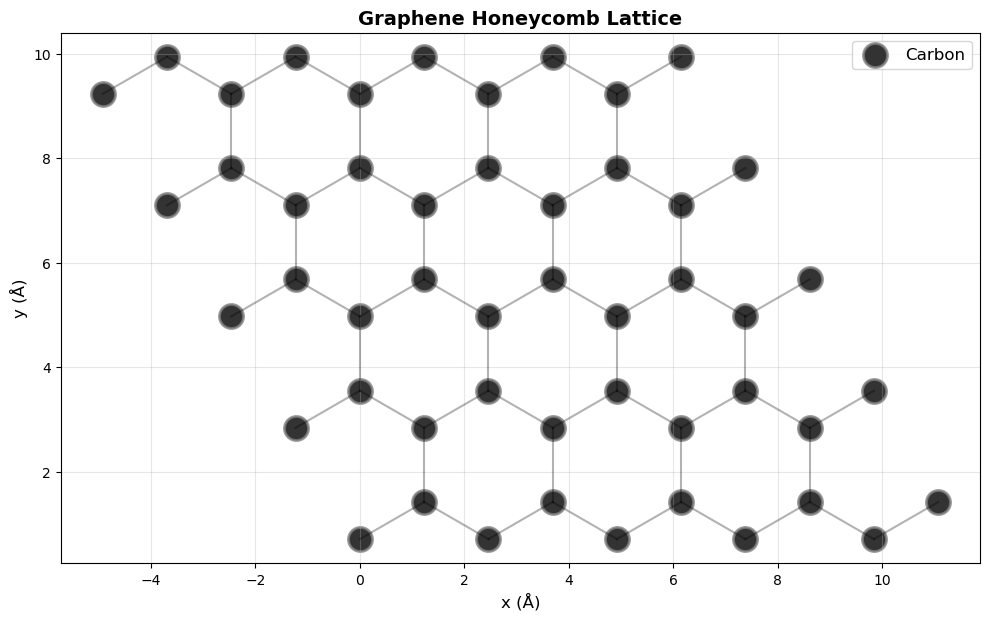

Total carbon atoms shown: 50
Typical C-C bond length: 1.42 Å


In [7]:
# Visualize graphene honeycomb lattice
structure = graphene.build_structure(nx=5, ny=5)
positions = structure.get_positions()

fig, ax = plt.subplots(1, 1, figsize=(10, 10))

# Plot carbon atoms
ax.scatter(positions[:, 0], positions[:, 1], s=300, c='black', 
           alpha=0.8, edgecolors='gray', linewidths=2, label='Carbon')

# Draw bonds (simplified - connect nearest neighbors)
bond_length = 1.42  # C-C bond length in Angstroms
tolerance = 0.1

for i, pos1 in enumerate(positions):
    for j, pos2 in enumerate(positions[i+1:], i+1):
        dist = np.linalg.norm(pos1[:2] - pos2[:2])
        if abs(dist - bond_length) < tolerance:
            ax.plot([pos1[0], pos2[0]], [pos1[1], pos2[1]], 
                   'k-', alpha=0.3, linewidth=1.5)

ax.set_xlabel('x (Å)', fontsize=12)
ax.set_ylabel('y (Å)', fontsize=12)
ax.set_title('Graphene Honeycomb Lattice', fontsize=14, fontweight='bold')
ax.set_aspect('equal')
ax.grid(True, alpha=0.3)
ax.legend(fontsize=12)

plt.tight_layout()
plt.show()

print(f"Total carbon atoms shown: {len(positions)}")
print(f"Typical C-C bond length: {bond_length} Å")


### 2.3 Graphene Quantum CTEM Workflow

In [8]:
# Initialize Graphene workflow (lower voltage and Cs are typical for graphene)
graphene_workflow = GrapheneWorkflow(backend=backend, voltage=80e3, cs=0.5)
print(f"Scherzer defocus: {graphene_workflow.microscope.defocus:.1f} Å")

# grid_size x pixel_size = 10.24x10.24 A, matched to the 4x4 graphene
# supercell (9.84x8.52 A) built below.
print("\nRunning quantum CTEM simulation...")
result_graphene = graphene_workflow.run(
    nx=4, ny=4, grid_size=128, pixel_size=0.08,
    apply_ctf=True, compare_classical=True,
)

print("\nSimulation complete!")
print(result_graphene.summary())


Scherzer defocus: -548.3 Å

Running quantum CTEM simulation...



Simulation complete!
=== Quantum CTEM Simulation Result ===
Material: Graphene
Supercell: 4×4 (32 atoms)
Grid: 128×128 px (0.080 Å/px)
Field of view: 9.8×8.5 Å

Quantum Circuit:
  Qubits: 14
  Depth: 5
  Execution time: 8.160 s

Microscope:
  Voltage: 80 kV
  Defocus: -548.3 Å
  Cs: 0.5 mm

Validation:
  Correlation with classical: 1.0000


### 2.4 Analyze Graphene Results

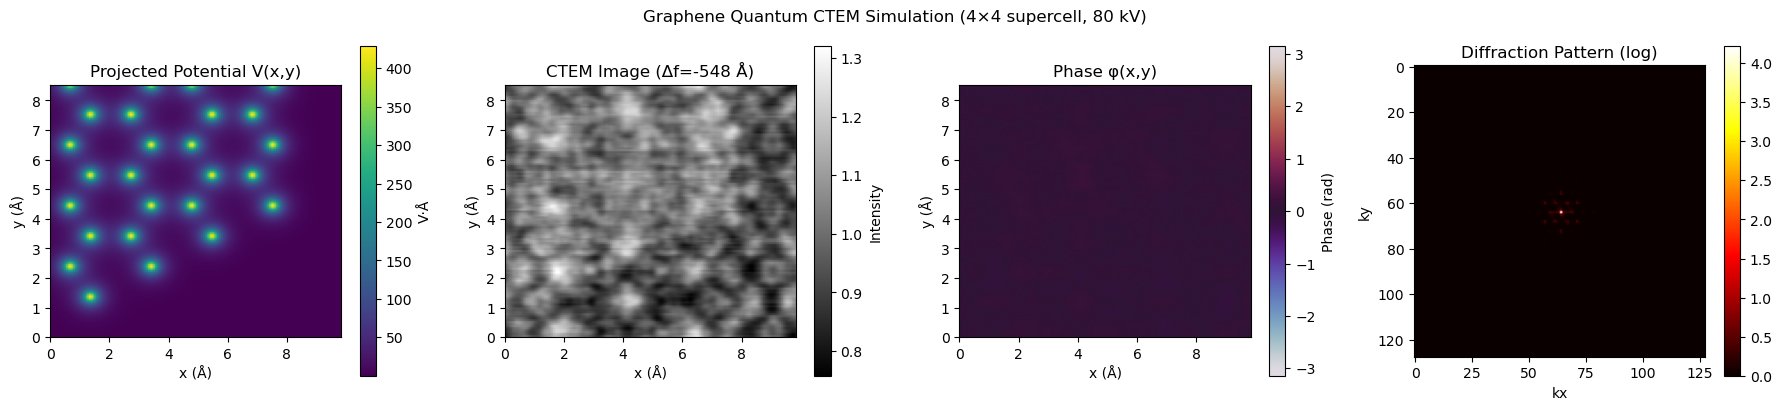

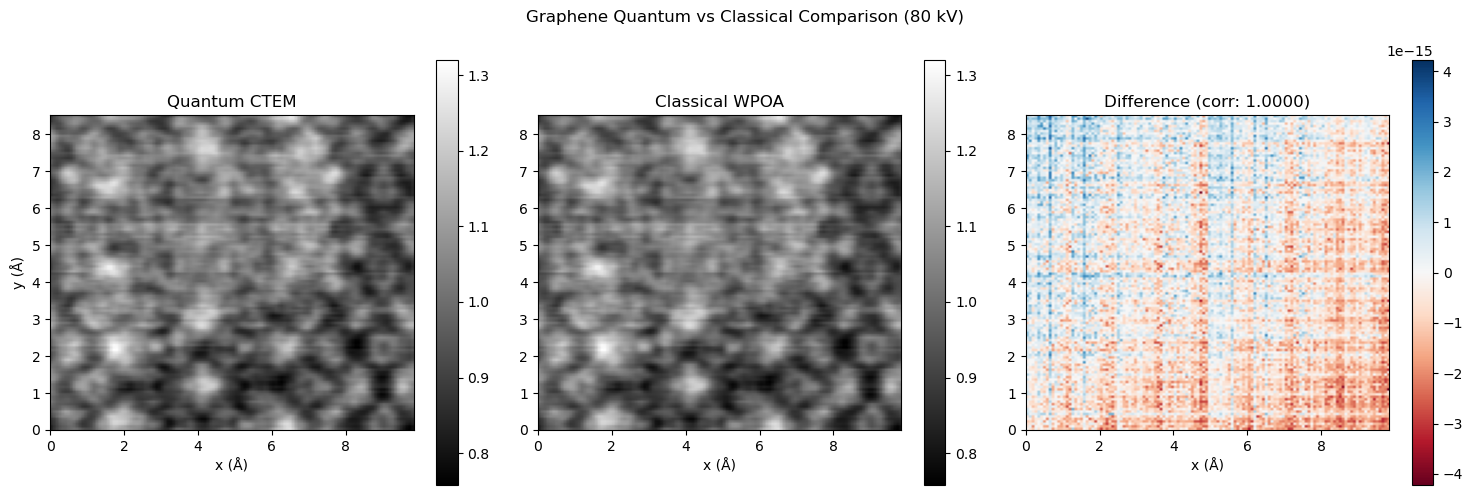

Potential range: [0.00, 428.47] V·Å
Circuit: 14 qubits, depth 5
Quantum-classical correlation: 1.000000


In [9]:
# Visualize graphene results (GrapheneWorkflow.visualize shows an FFT/
# diffraction panel in place of MoS2Workflow'''s CTF-curve panel)
fig = graphene_workflow.visualize(
    result_graphene, show_potential=True, show_intensity=True, show_phase=True,
    show_fft=True, figsize=(18, 4),
)
plt.show()

# GrapheneWorkflow has no built-in compare_with_classical helper (unlike
# MoS2Workflow), so build the same quantum/classical/difference panel inline.
extent = [0, result_graphene.field_of_view[0], 0, result_graphene.field_of_view[1]]
fig2, axes = plt.subplots(1, 3, figsize=(15, 5))
im0 = axes[0].imshow(result_graphene.intensity, cmap='gray', extent=extent)
axes[0].set_title('Quantum CTEM'); axes[0].set_xlabel('x (Å)'); axes[0].set_ylabel('y (Å)')
plt.colorbar(im0, ax=axes[0])
im1 = axes[1].imshow(result_graphene.classical_intensity, cmap='gray', extent=extent)
axes[1].set_title('Classical WPOA'); axes[1].set_xlabel('x (Å)')
plt.colorbar(im1, ax=axes[1])
diff = result_graphene.intensity - result_graphene.classical_intensity
max_diff = np.max(np.abs(diff)) + 1e-20
im2 = axes[2].imshow(diff, cmap='RdBu', extent=extent, vmin=-max_diff, vmax=max_diff)
axes[2].set_title(f'Difference (corr: {result_graphene.correlation_coefficient:.4f})')
axes[2].set_xlabel('x (Å)')
plt.colorbar(im2, ax=axes[2])
plt.suptitle(f'Graphene Quantum vs Classical Comparison ({graphene_workflow.microscope.voltage/1e3:.0f} kV)')
plt.tight_layout()
plt.show()

print(f"Potential range: [{result_graphene.projected_potential.min():.2f}, "
      f"{result_graphene.projected_potential.max():.2f}] V·Å")
print(f"Circuit: {result_graphene.n_qubits} qubits, depth {result_graphene.circuit_depth}")
print(f"Quantum-classical correlation: {result_graphene.correlation_coefficient:.6f}")


**A note on image appearance:** the CTEM images above can look grainy/speckled
rather than showing crisp atomic contrast. This is a genuine, validated numerical
effect, not a bug: at Scherzer defocus the lens aberration function chi(k) oscillates
extremely rapidly in k, and this notebook uses a deliberately small field of view
(≈10 Å) for fast execution, so the k-space grid spacing is far coarser than chi(k)'s
own oscillation period -- the CTF is aliased. (Quantum-classical correlation is still
exactly 1.000000: the quantum circuit reproduces this aliased CTF perfectly, since it
implements exactly the same discrete chi(k) as the classical twin.) A production
simulation would use a much larger field of view (hundreds of Å) so chi(k) is properly
resolved; try increasing ``grid_size`` (at fixed pixel_size) to see the image sharpen.

## Part 3: Comparing MoS₂ and Graphene

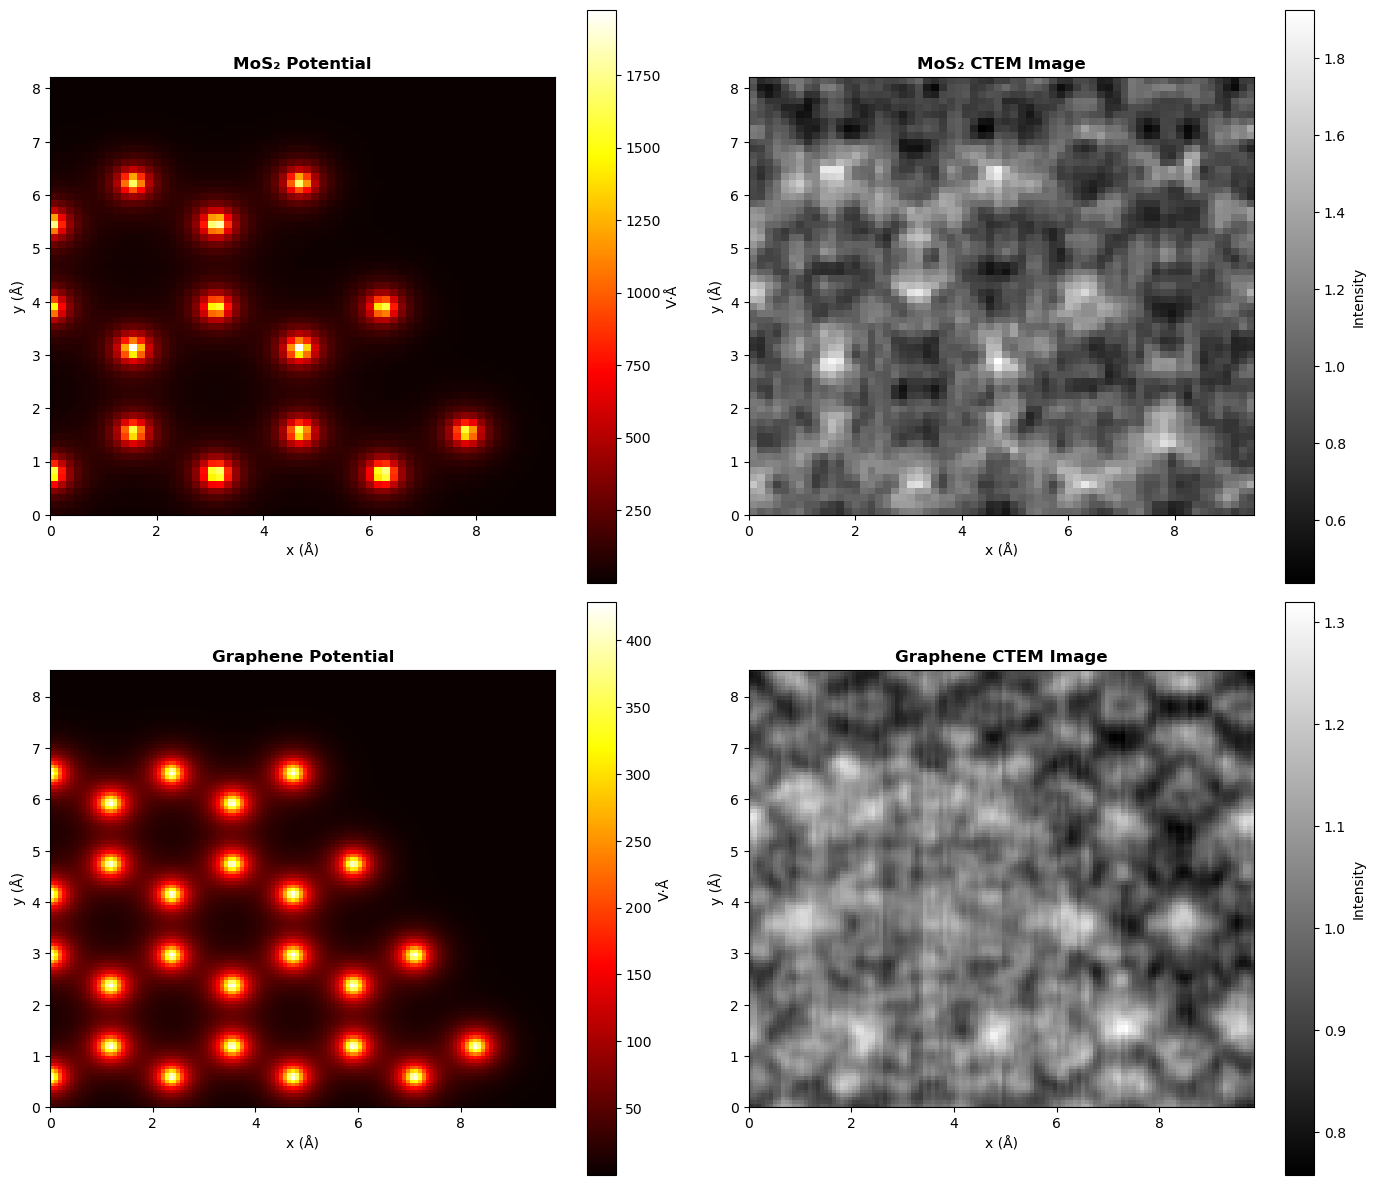


Material Comparison:

MoS₂:
  Lattice constant: 3.160 Å
  Circuit qubits: 12
  Potential range: [4.64e-04, 1.98e+03] V·Å
  Quantum-classical correlation: 1.000000

Graphene:
  Lattice constant: 2.460 Å
  Circuit qubits: 14
  Potential range: [7.39e-06, 4.28e+02] V·Å
  Quantum-classical correlation: 1.000000

Note: MoS₂ contains heavy Mo (Z=42) and S (Z=16) atoms, which scatter
far more strongly than graphene's light carbon (Z=6) -- directly visible
in the ~2 order-of-magnitude difference in potential range above, and the
reason MoS2 is a much easier WPOA imaging target than graphene.


In [10]:
# Side-by-side comparison
fig, axes = plt.subplots(2, 2, figsize=(14, 12))

extent_mos2 = [0, result.field_of_view[0], 0, result.field_of_view[1]]
extent_gr = [0, result_graphene.field_of_view[0], 0, result_graphene.field_of_view[1]]

im1 = axes[0, 0].imshow(result.projected_potential.T, cmap='hot', extent=extent_mos2, origin='lower')
axes[0, 0].set_title('MoS₂ Potential', fontsize=12, fontweight='bold')
axes[0, 0].set_xlabel('x (Å)'); axes[0, 0].set_ylabel('y (Å)')
plt.colorbar(im1, ax=axes[0, 0], label='V·Å')

im2 = axes[0, 1].imshow(result.intensity.T, cmap='gray', extent=extent_mos2, origin='lower')
axes[0, 1].set_title('MoS₂ CTEM Image', fontsize=12, fontweight='bold')
axes[0, 1].set_xlabel('x (Å)'); axes[0, 1].set_ylabel('y (Å)')
plt.colorbar(im2, ax=axes[0, 1], label='Intensity')

im3 = axes[1, 0].imshow(result_graphene.projected_potential.T, cmap='hot', extent=extent_gr, origin='lower')
axes[1, 0].set_title('Graphene Potential', fontsize=12, fontweight='bold')
axes[1, 0].set_xlabel('x (Å)'); axes[1, 0].set_ylabel('y (Å)')
plt.colorbar(im3, ax=axes[1, 0], label='V·Å')

im4 = axes[1, 1].imshow(result_graphene.intensity.T, cmap='gray', extent=extent_gr, origin='lower')
axes[1, 1].set_title('Graphene CTEM Image', fontsize=12, fontweight='bold')
axes[1, 1].set_xlabel('x (Å)'); axes[1, 1].set_ylabel('y (Å)')
plt.colorbar(im4, ax=axes[1, 1], label='Intensity')

plt.tight_layout()
plt.show()

# Comparison statistics
print("\nMaterial Comparison:")
print("\nMoS₂:")
print(f"  Lattice constant: {mos2.parameters.a:.3f} Å")
print(f"  Circuit qubits: {result.n_qubits}")
print(f"  Potential range: [{result.projected_potential.min():.2e}, {result.projected_potential.max():.2e}] V·Å")
print(f"  Quantum-classical correlation: {result.correlation_coefficient:.6f}")

print("\nGraphene:")
print(f"  Lattice constant: {graphene.parameters.a:.3f} Å")
print(f"  Circuit qubits: {result_graphene.n_qubits}")
print(f"  Potential range: [{result_graphene.projected_potential.min():.2e}, {result_graphene.projected_potential.max():.2e}] V·Å")
print(f"  Quantum-classical correlation: {result_graphene.correlation_coefficient:.6f}")

print("\nNote: MoS₂ contains heavy Mo (Z=42) and S (Z=16) atoms, which scatter")
print("far more strongly than graphene's light carbon (Z=6) -- directly visible")
print("in the ~2 order-of-magnitude difference in potential range above, and the")
print("reason MoS2 is a much easier WPOA imaging target than graphene.")
